In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('healthcare_dataset.csv')

In [3]:
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [5]:
data.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [6]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
55495    False
55496    False
55497    False
55498    False
55499    False
Length: 55500, dtype: bool

In [7]:
data.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [8]:
data['Medical Condition'].value_counts()

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

In [9]:
data['Test Results'].value_counts()

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

In [10]:
pd.crosstab(data['Medical Condition'],data['Test Results'])

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,3188,3088,3032
Asthma,3009,3029,3147
Cancer,3118,3060,3049
Diabetes,3168,3046,3090
Hypertension,3012,3091,3142
Obesity,3132,3042,3057


In [11]:
pd.crosstab(data['Blood Type'],data['Test Results'])

Test Results,Abnormal,Inconclusive,Normal
Blood Type,,,
A+,2333,2330,2293
A-,2336,2298,2335
AB+,2308,2325,2314
AB-,2333,2250,2362
B+,2303,2366,2276
B-,2348,2268,2328
O+,2347,2262,2308
O-,2319,2257,2301


In [12]:
data['Medication'].value_counts()

Medication
Lipitor        11140
Ibuprofen      11127
Aspirin        11094
Paracetamol    11071
Penicillin     11068
Name: count, dtype: int64

In [13]:
pd.crosstab(data['Medication'],data['Test Results'])

Test Results,Abnormal,Inconclusive,Normal
Medication,,,
Aspirin,3732,3624,3738
Ibuprofen,3747,3645,3735
Lipitor,3707,3746,3687
Paracetamol,3737,3681,3653
Penicillin,3704,3660,3704


In [14]:
data.shape

(55500, 15)

In [15]:
data['Admission Type'].value_counts()

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

In [16]:
pd.crosstab(data['Admission Type'],data['Test Results'])

Test Results,Abnormal,Inconclusive,Normal
Admission Type,,,
Elective,6296,6118,6241
Emergency,6091,6072,6106
Urgent,6240,6166,6170


In [17]:
Q1=data['Room Number'].quantile(0.25)
Q3=data['Room Number'].quantile(0.75)
IQR=Q3-Q1
low=Q1-1.5*IQR
high=Q3+1.5*IQR
outliers=data[(data['Room Number']<low)|(data['Room Number']>high)]
outliers

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


In [18]:
Q1=data['Age'].quantile(0.25)
Q3=data['Age'].quantile(0.75)
IQR=Q3-Q1
low=Q1-1.5*IQR
high=Q3+1.5*IQR
outliers=data[(data['Age']<low)|(data['Age']>high)]
outliers

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


In [19]:
Q1=data['Billing Amount'].quantile(0.25)
Q3=data['Billing Amount'].quantile(0.75)
IQR=Q3-Q1
low=Q1-1.5*IQR
high=Q3+1.5*IQR
outliers=data[(data['Billing Amount']<low)|(data['Billing Amount']>high)]
outliers

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results


In [20]:
data.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

### So here we can conclude there are no outliers in numerical or categorical columns in general and no duplicate values are there and along with that no missing values are there.

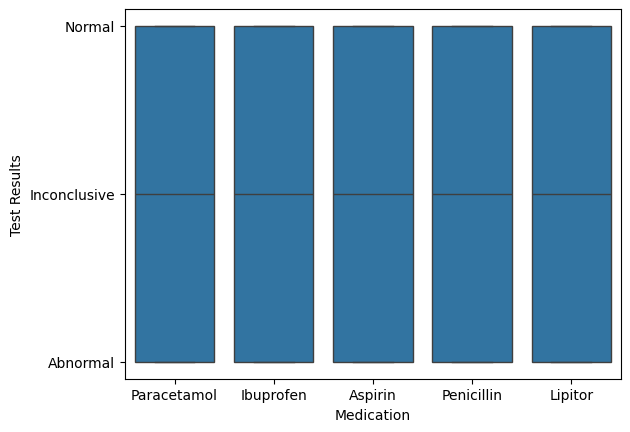

In [21]:
sns.boxplot(data=data,x='Medication',y='Test Results');

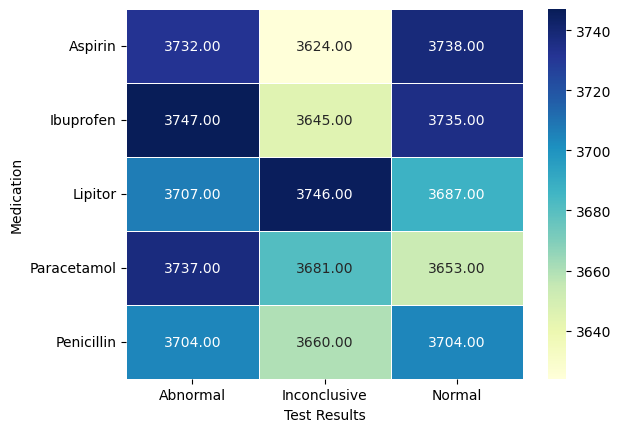

In [22]:
sns.heatmap(pd.crosstab(data['Medication'],data['Test Results']),annot=True,fmt='.2f',cmap='YlGnBu',linewidth=0.5);

* So here we can see that the patients having `Lipitor` are more prone to getting Inconclusice results
* While People with `Ibuprofen` are more prone towards haivng a Abnormal Test results and the same goes with people undergoing `Paracetamol` medication
* People undergoing `Aspirin` medication are equally distributed among the `Normal` and `Abnormal` Test results 

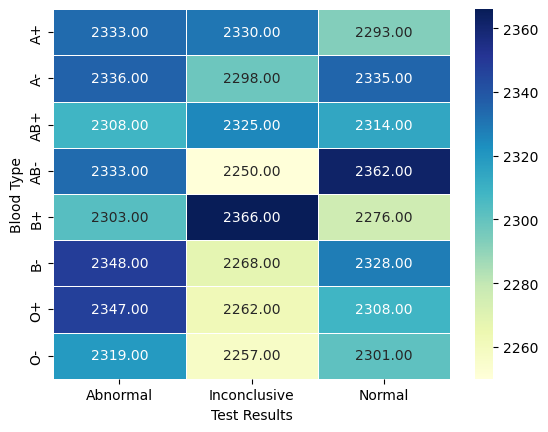

In [23]:
sns.heatmap(pd.crosstab(data['Blood Type'],data['Test Results']),annot=True,fmt='.2f',cmap='YlGnBu',linewidth=0.5);

* People with Blood Group `AB-` are more likely to have a `Normal` Test Results.
* People with Blood Group `B+` are more likely to have a `Inconclusive` Test Results
* While people with Blood Group `O+` and `B-` are more likely to get a `Abnormal` Test Results however they have somewhat less likely to have a `Inconclusive` Test Results.
   

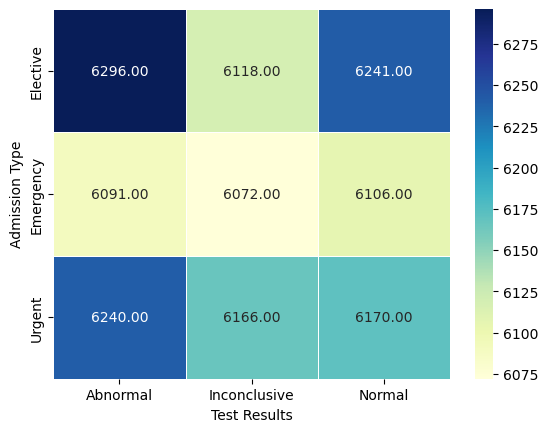

In [24]:
sns.heatmap(pd.crosstab(data['Admission Type'],data['Test Results']),annot=True,fmt='.2f',cmap='YlGnBu',linewidth=0.5);

* From this heatmap we can conclude that people having `Admission type` as `Elective` are more likely to have an `Abnormal` Test Results this same argument goes for people with `Urgent Admission Type` are also tend to get a more `Abnormal` Test Results but lesser in count than the `Elective` one.
* `Elective` are also more likely to have a `Normal` Test Results but lesser than the `Abnormal` ones so its a little contradictory.
* However the `Emergency` Admission type is quite evenly distributed between `Abnormal`,`Normal` and `Inconclusive` Test Results.

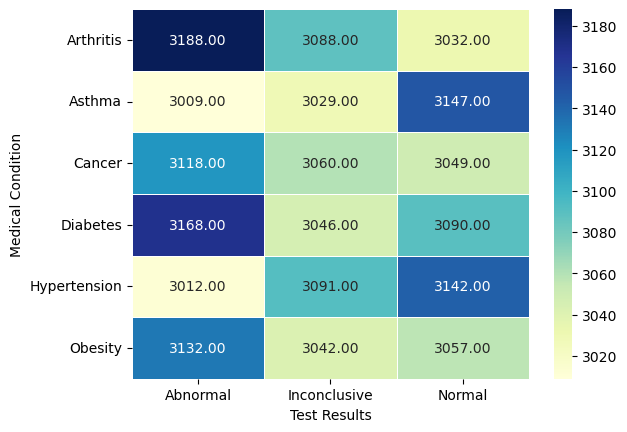

In [25]:
sns.heatmap(pd.crosstab(data['Medical Condition'],data['Test Results']),annot=True,fmt='.2f',cmap='YlGnBu',linewidth=0.5);

* People with `Arthritis` are more likely to have an `Abnormal` Test Result.
* People with `Asthama` are more likely to have a `Normal` Test Result.
* People with `Cancer`,`Diabetes` and `Obesity` are more likely to have an `Abnormal` Test Result however the most out of the 3 is `Diabetes`.
* People with `Hypertension` are more likely to have a `Normal` Test Results.

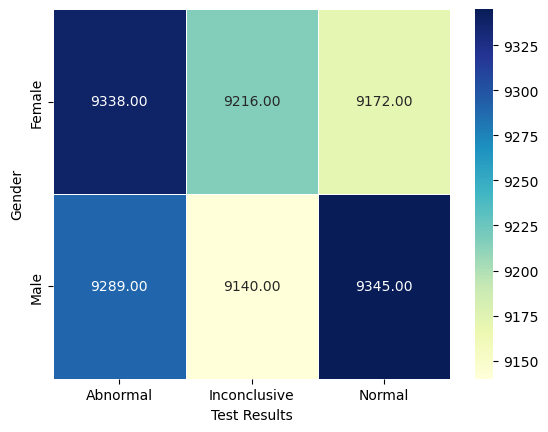

In [26]:
sns.heatmap(pd.crosstab(data['Gender'],data['Test Results']),annot=True,fmt='.2f',cmap='YlGnBu',linewidth=0.5);

* From this heatmap we can safely say that `Males` are more likely to happen a `Normal` Test Results and then comes `Abnormal`.
* `Females` are more likely to have an `Abnormal` Test Results. 

In [27]:
data['Hospital'].value_counts()

Hospital
LLC Smith                      44
Ltd Smith                      39
Johnson PLC                    38
Smith Ltd                      37
Smith PLC                      36
                               ..
and Montoya Flores, Boyer       1
Carter and Dunn King,           1
Hall, Brown Black and           1
Peterson Scott and Thomas,      1
Moreno Murphy, Griffith and     1
Name: count, Length: 39876, dtype: int64

The `Hospital` column is quite saturated so we can safely avoid that for the sake of simplicity from EDA.

In [28]:
data.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [31]:
data['Hospital'].value_counts()

Hospital
LLC Smith                      44
Ltd Smith                      39
Johnson PLC                    38
Smith Ltd                      37
Smith PLC                      36
                               ..
and Montoya Flores, Boyer       1
Carter and Dunn King,           1
Hall, Brown Black and           1
Peterson Scott and Thomas,      1
Moreno Murphy, Griffith and     1
Name: count, Length: 39876, dtype: int64

In [32]:
data['Insurance Provider'].value_counts()

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

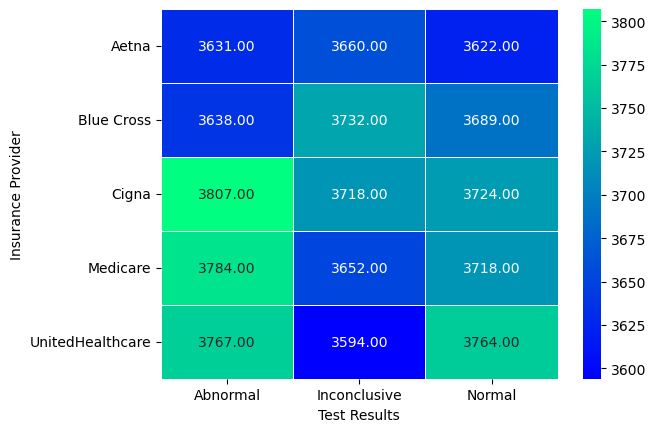

In [34]:
sns.heatmap(pd.crosstab(data['Insurance Provider'],data['Test Results']),cmap='winter',linewidth=0.5,fmt='.2f',annot=True);

In [35]:
data['Date of Admission'].value_counts()

Date of Admission
2024-03-16    50
2022-07-24    49
2020-10-22    49
2021-12-28    48
2021-01-03    48
              ..
2023-04-12    14
2022-05-28    14
2022-05-23    13
2019-07-22    13
2022-02-05    12
Name: count, Length: 1827, dtype: int64

In [36]:
data.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [37]:
data['Room Number'].value_counts()

Room Number
393    181
491    177
104    175
420    175
209    171
      ... 
253    112
254    111
257    111
381    110
398    109
Name: count, Length: 400, dtype: int64

In [39]:
data.drop(columns=['Name','Date of Admission','Doctor','Hospital','Room Number'],inplace=True)

In [40]:
data.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal


In [42]:
data.drop(columns='Discharge Date',inplace=True)

In [43]:
data.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin,Abnormal


In [44]:
data['Billing Amount'].value_counts()

Billing Amount
8926.285937     2
50762.528342    2
24366.680481    2
14042.748908    2
18253.980486    2
               ..
43748.820505    1
8416.227513     1
25815.037193    1
20761.261421    1
40116.177618    1
Name: count, Length: 50000, dtype: int64

In [45]:
data.drop(columns='Billing Amount',inplace=True)

In [46]:
data.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,Blue Cross,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,Medicare,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,Aetna,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,Medicare,Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,Aetna,Urgent,Penicillin,Abnormal


In [49]:
data.columns

Index(['Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Insurance Provider', 'Admission Type', 'Medication', 'Test Results'],
      dtype='object')

In [50]:
data['Age'].value_counts()

Age
38    897
37    893
57    887
80    864
34    864
     ... 
88     25
16     24
14     18
13     14
89      8
Name: count, Length: 77, dtype: int64

In [51]:
data['Age_Group']=pd.cut(
    data['Age'],
    bins=[0,30,60,120],
    labels=['Young','Middle Aged','Senior']
)
print([data['Age'],data['Age_Group']])

[0        30
1        62
2        76
3        28
4        43
         ..
55495    42
55496    61
55497    38
55498    43
55499    53
Name: Age, Length: 55500, dtype: int64, 0              Young
1             Senior
2             Senior
3              Young
4        Middle Aged
            ...     
55495    Middle Aged
55496         Senior
55497    Middle Aged
55498    Middle Aged
55499    Middle Aged
Name: Age_Group, Length: 55500, dtype: category
Categories (3, object): ['Young' < 'Middle Aged' < 'Senior']]


In [52]:
data.head()

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results,Age_Group
0,30,Male,B-,Cancer,Blue Cross,Urgent,Paracetamol,Normal,Young
1,62,Male,A+,Obesity,Medicare,Emergency,Ibuprofen,Inconclusive,Senior
2,76,Female,A-,Obesity,Aetna,Emergency,Aspirin,Normal,Senior
3,28,Female,O+,Diabetes,Medicare,Elective,Ibuprofen,Abnormal,Young
4,43,Female,AB+,Cancer,Aetna,Urgent,Penicillin,Abnormal,Middle Aged


In [53]:
data.drop(columns='Age',inplace=True)

In [54]:
data.head()

,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results,Age_Group
0,Male,B-,Cancer,Blue Cross,Urgent,Paracetamol,Normal,Young
1,Male,A+,Obesity,Medicare,Emergency,Ibuprofen,Inconclusive,Senior
2,Female,A-,Obesity,Aetna,Emergency,Aspirin,Normal,Senior
3,Female,O+,Diabetes,Medicare,Elective,Ibuprofen,Abnormal,Young
4,Female,AB+,Cancer,Aetna,Urgent,Penicillin,Abnormal,Middle Aged


In [55]:
X=data.drop(columns='Test Results')
y=data['Test Results']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [56]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [57]:
data.dtypes

Gender                  object
Blood Type              object
Medical Condition       object
Insurance Provider      object
Admission Type          object
Medication              object
Test Results            object
Age_Group             category
dtype: object

In [58]:
cat_pipeline=Pipeline(
    steps=[
        ('one_hot_encoder',OneHotEncoder(handle_unknown='ignore')),
        ('scaler',StandardScaler(with_mean=False))
    ]
)

In [59]:
cat_columns=[
    'Gender',
    'Blood Type',
    'Medical Condition',      
    'Insurance Provider',     
    'Admission Type',         
    'Medication',             
    'Age_Group'             
]

In [60]:
preprocessor=ColumnTransformer(
    [
        ('cat_pipeline',cat_pipeline,cat_columns)
    ]
)

In [61]:
label_enc=LabelEncoder()

In [62]:
X_train_new=preprocessor.fit_transform(X_train)
y_train_new=label_enc.fit_transform(y_train)

In [66]:
X_test.shape,X_train.shape,y_train.shape,y_test.shape

((11100, 7), (44400, 7), (44400,), (11100,))

In [67]:
X_test_new=preprocessor.transform(X_test)
y_test_new=label_enc.transform(y_test)

In [69]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   - -------------------------------------- 3.4/72.0 MB 18.0 MB/s eta 0:00:04
   ---- ----------------------------------- 7.3/72.0 MB 17.7 MB/s eta 0:00:04
   ----- ---------------------------------- 9.4/72.0 MB 15.3 MB/s eta 0:00:05
   ------ --------------------------------- 11.8/72.0 MB 14.1 MB/s eta 0:00:05
   ------- -------------------------------- 13.9/72.0 MB 13.2 MB/s eta 0:00:05
   --------- ------------------------------ 16.8/72.0 MB 13.2 MB/s eta 0:00:05
   ----------- ---------------------------- 19.9/72.0 MB 13.4 MB/s eta 0:00:04
   ------------ --------------------------- 23.1/72.0 MB 13.5 MB/s eta 0:00:04
   -------------- ------------------------- 26.7/72.0 MB 13.9 MB/s eta 0:00:04
   ---------------- ----------------------- 30.4/72.0 MB 14.3 MB/s eta 0:00:03
   ------------------ --------------------- 32.5/72.0 MB 14.0 MB/s eta 0:00:03
   ------------------ --------------------- 33.3/72.0 MB 13.6 MB

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV